# Project 2 in numdiff


In [2]:
#Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Problem 1

In [3]:
#Create the partition 
def partition(X):  
    Tau_h = np.array([[a,(a+b)/2, b] for a, b in zip(X[0:-1], X[1:])])
    return Tau_h

# Define the phi derivatives functions
def phi0(x):
    return 2*x*x-3*x+1

def phi1(x):
    return -4*x*x+4*x

def phi2(x):
    return 2*x*x-x

# Define the global mapping function
def mapping(K, xi):
    h = K[2] - K[0]
    return K[0] + h*xi

# Define the local to global index mapping function
def local_to_global(k,a):
    return 2*k+a

#simpson algorithm from wikipedia
def simpson(f):
    return (1/6) * (f(0) + 4*f(0.5) + f(1))

#Matrix calculated from integrals in the overleaf document
def Ak(h):
    return 1/(3*h)* np.array([[7, -8, 1], [-8, 16 ,-8], [1, -8, 7]])


def Fk(f, K):
    fk = np.zeros(3)
    h = K[2] - K[0]
    fk[0] = h * simpson(lambda x : f(mapping(K,x))*phi0(x))
    fk[1] = h * simpson(lambda x : f(mapping(K,x))*phi1(x))
    fk[2] = h * simpson(lambda x : f(mapping(K,x))*phi2(x))
    return fk


#Makes the big Matrix
def assembly(partition, func):
    
    p = np.shape(partition)[0]
    m = 3*p - (p-1)
    A = np.zeros((m,m))
    F = np.zeros((m))

    for k in range(p):
        hk = partition[k][2] - partition[k][0]
        ak = Ak(hk)
        fk = Fk(func, partition[k])
        for alpha in range(3):
            i = local_to_global(k,alpha)
            for beta in range(3):
                j = local_to_global(k,beta)
                A[i][j] = A[i][j] + ak[alpha][beta]
            F[i] += fk[alpha]
    return A , F

def g(x):
    return 1



#modifies the boundary of the big matrix
def modify_boundary(A):
    A[0] = np.zeros(len(A[0]))
    A[-1] = np.zeros(len(A[0]))
    A[0][0] = 1
    A[-1][-1] = 1
    return A

#modified the boundary of the vector for the np.linalg.solve
def modify_vector_boundary(v,a,b):
    v[0]=a
    v[len(v)-1]=b
    return v



#exact solution for comparison
def exact_solution(x):
    return -(1/2)*x*(x-1)



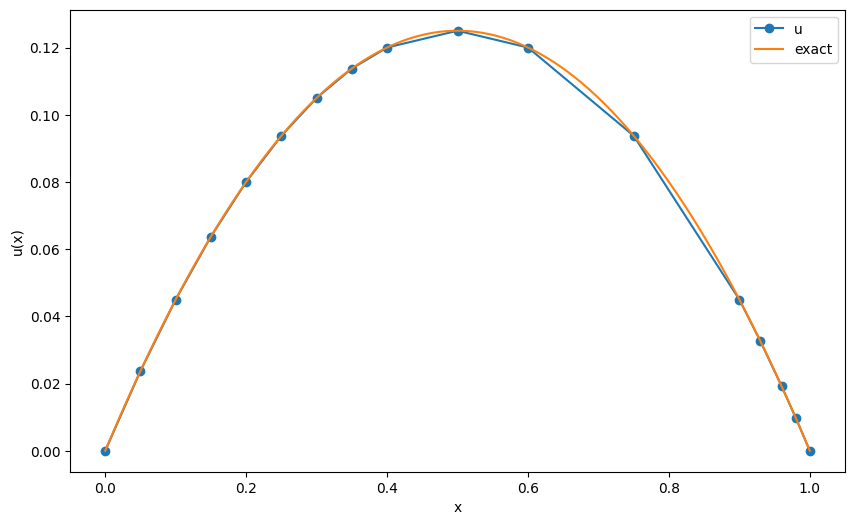

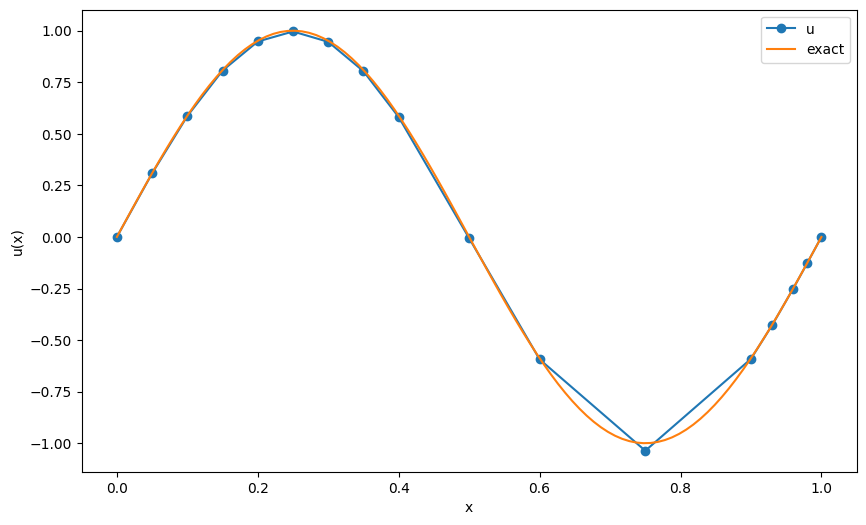

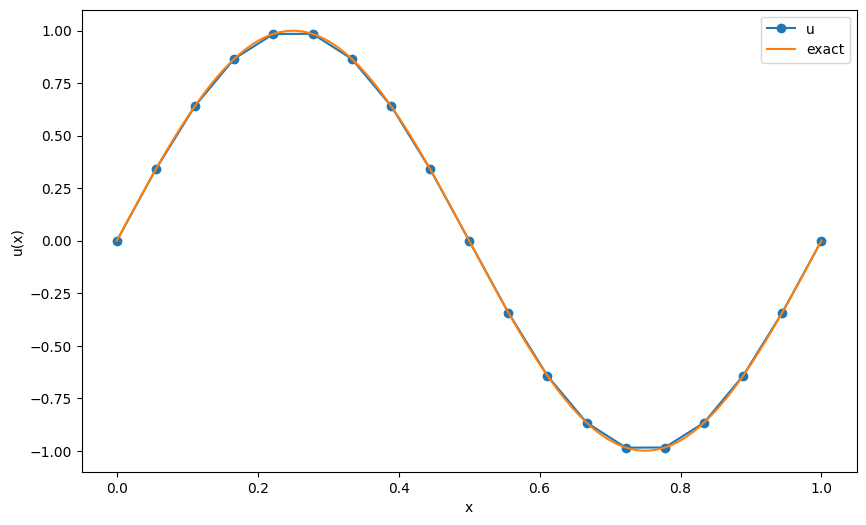

In [4]:

def problem1(g, X): 
    
    tau = partition(X)
    
    Xi = []

    for i in range(len(X) - 1):
        Xi.append(X[i])  
        Xi.append((X[i] + X[i+1]) / 2)  # Add midpoint

    Xi.append(X[-1])  # Add the last original point


    a, F = assembly(tau, g)
    a = modify_boundary(a)
    F = modify_vector_boundary(F,0,0)
    # print("F:",F)
    u = np.linalg.solve(a,F)

    return u, Xi

def plot_solution(u, Xi, exact_solution):
    plt.figure(figsize=(10, 6))
    x = np.linspace(0,1,100)
    plt.plot(Xi, u, "-o", label='u')
    plt.plot(x, exact_solution(x), label='exact')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.show()

X = [0,0.1,0.2,0.3,0.4,0.6,0.9, 0.96,1]  

u, xi= problem1(g, X)

plot_solution(u, xi, exact_solution)




def u_1(x):
    return np.sin(2*np.pi*x)

def f_1(x):
    return 4*np.pi**2 * np.sin(2*np.pi*x)

u, xi = problem1(f_1, X)

plot_solution(u, xi, u_1)


X = np.linspace(0,1,10)  # Create a finer grid for plotting

u, xi= problem1(f_1, X)

plot_solution(u, xi, u_1)

Mesh size (h) | L2 error ||u - u_h|| | Order of convergence
0.20000     | 5.47723e-03         | 1.96
0.10000     | 1.40683e-03         | 1.98
0.05000     | 3.56305e-04         | 1.99
0.02500     | 8.96454e-05         | 2.00
0.01250     | 2.24822e-05         | 2.00
0.00625     | 5.62937e-06         | 2.00
0.00313     | 1.40844e-06         | 2.00


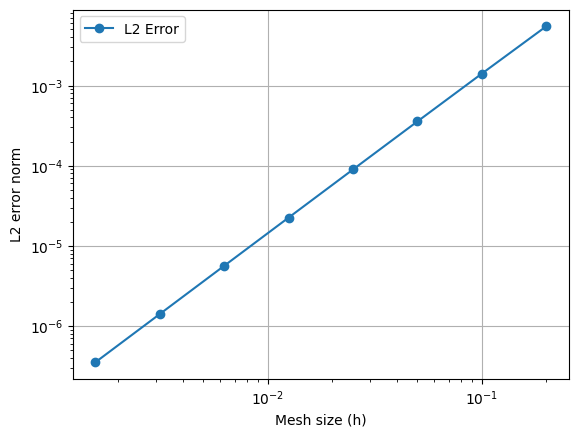

In [ ]:


def compute_L2_error(u_h, nodes, exact_solution):
    error_integral = 0.0

    
    for i in range(len(nodes) - 2):
        
        error_left = (exact_solution(nodes[i]) - u_h[i])**2
        error_mid = (exact_solution(nodes[i+1]) - (u_h[i] + u_h[i+2])/2 )**2
        error_right = (exact_solution(nodes[i+2]) - u_h[i+2])**2
        
        h = nodes[i+2] - nodes[i]
        error_integral += (h / 6) * (error_left + 4 * error_mid + error_right)
    
    return np.sqrt(error_integral)


mesh_sizes = [1/5, 1/10, 1/20, 1/40, 1/80, 1/160, 1/320, 1/640]  
errors = []

for h in mesh_sizes:
    X = np.arange(0, 1 + h, h)  # Create partition
    u_h, nodes = problem1(g, X)  # Compute numerical solution
    error = compute_L2_error(u_h, nodes, exact_solution)
    errors.append(error)

# Compute order of convergence
orders = [np.log(errors[i] / errors[i+1]) / np.log(2) for i in range(len(errors) - 1)]



# Print results
print("Mesh size (h) | L2 error ||u - u_h|| | Order of convergence")
for i in range(len(errors) -1):
    print(f"{mesh_sizes[i]:.5f}     | {errors[i]:.5e}         | {orders[i]:.2f}")

# Plot error convergence
plt.loglog(mesh_sizes, errors, "-o", label="L2 Error")
plt.xlabel("Mesh size (h)")
plt.ylabel("L2 error norm")
plt.legend()
plt.grid(True)
plt.show()

Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence
0.20000     | 7.76531e-02         | 0.96
0.10000     | 3.98160e-02         | 0.98
0.05000     | 2.01588e-02         | 0.99
0.02500     | 1.01426e-02         | 1.00
0.01250     | 5.08718e-03         | 1.00
0.00625     | 2.54757e-03         | 1.00
0.00313     | 1.27478e-03         | 1.00


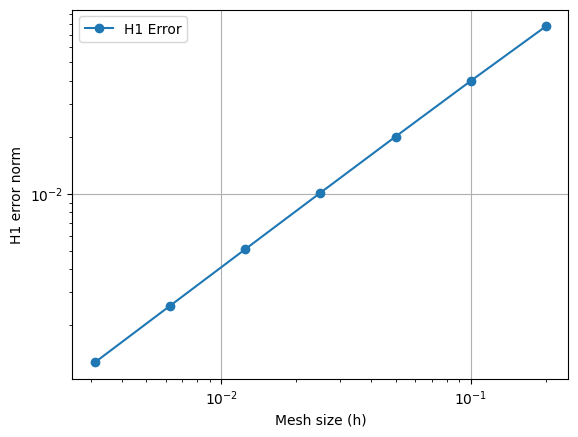

In [ ]:
def compute_H1_error(u_h, nodes, exact_solution, exact_derivative):
    error_integral_L2 = 0.0
    error_integral_H1 = 0.0

    for i in range(len(nodes) - 2):
        
        error_left = (exact_solution(nodes[i]) - u_h[i])**2
        error_mid = (exact_solution(nodes[i+1]) - (u_h[i] + u_h[i+2])/2 )**2
        error_right = (exact_solution(nodes[i+2]) - u_h[i+2])**2
        
        h = nodes[i+2] - nodes[i]
        error_integral_L2 += (h / 6) * (error_left + 4 * error_mid + error_right)
        
        # H1 semi-norm error (derivative part)
        uh_prime = (u_h[i+2] - u_h[i]) / h  # Numerical derivative (linear approx)
        
        error_deriv_left = (exact_derivative(nodes[i]) - uh_prime)**2
        error_deriv_mid = (exact_derivative(nodes[i+1]) - uh_prime)**2
        error_deriv_right = (exact_derivative(nodes[i+2]) - uh_prime)**2
        
        error_integral_H1 += (h / 6) * (error_deriv_left + 4 * error_deriv_mid + error_deriv_right)

    L2_error = np.sqrt(error_integral_L2)
    H1_seminorm_error = np.sqrt(error_integral_H1)
    
    H1_error = np.sqrt(L2_error**2 + H1_seminorm_error**2)
    
    return H1_error, L2_error, H1_seminorm_error

# Define exact derivative of the solution
def exact_solution_derivative(x):
    return - (x - 0.5)

# Compute H1 error for different mesh sizes
H1_errors = []
L2_errors = []
H1_seminorm_errors = []

for h in mesh_sizes:
    X = np.arange(0, 1 + h, h)  # Create an equidistant partition
    u_h, nodes = problem1(g, X)  # Compute numerical solution
    
    H1_error, L2_error, H1_seminorm_error = compute_H1_error(u_h, nodes, exact_solution, exact_solution_derivative)
    
    H1_errors.append(H1_error)
    L2_errors.append(L2_error)
    H1_seminorm_errors.append(H1_seminorm_error)

# Compute order of convergence
H1_orders = [np.log(H1_errors[i] / H1_errors[i+1]) / np.log(2) for i in range(len(H1_errors) - 1)]

# Print results
print("Mesh size (h) | H1 error ||u - u_h||_H1 | Order of convergence")
for i in range(len(H1_errors) - 1):
    print(f"{mesh_sizes[i]:.5f}     | {H1_errors[i]:.5e}         | {H1_orders[i]:.2f}")

# Plot H1 error convergence
plt.loglog(mesh_sizes[:-1], H1_errors[:-1], "-o", label="H1 Error")
plt.xlabel("Mesh size (h)")
plt.ylabel("H1 error norm")
plt.legend()
plt.grid(True)
plt.show()


## Problem 2


In [ ]:

def Ak2(h):
    return h/(15)* np.array([[2, 1, -1/2], [1, 8 , 1], [-1/2, 1, 2]])


def assembly2(partition):
    p = np.shape(partition)[0]
    m = 3*p - (p-1)
    A = np.zeros((m,m))

    for k in range(p):
        hk = partition[k][1] - partition[k][0]
        ak = Ak2(hk)
        
        for alpha in range(3):
            i = local_to_global(k,alpha)
            for beta in range(3):
                j = local_to_global(k,beta)
                A[i][j] = A[i][j] + ak[alpha][beta]
            
    return A 

def y_d1(x):
    return (1/2)*x*(1-x)

def y_d2(x):
    return 1

def y_d3(x):
    if x >0.25 and x < 0.75:
        return 1
    else:
        return 0


def optim(alpha, y_d):
    X = [0,0.1,0.2,0.3,0.35,0.4,0.45,0.6,0.9, 0.96,1]  


    tau = partition(X)
    
    combined = []

    for i in range(len(X) - 1):
        combined.append(X[i])  # Add original point
        combined.append((X[i] + X[i+1]) / 2)  # Add midpoint

    combined.append(X[-1])  # Add the last original point
    
    A = assembly2(tau)
    A = A[1:-1, 1:-1]

    Abar = assembly2(tau)
    Abar = Abar[:,1:-1]
    
    Aprime, F = assembly(tau, g)
    Aprime = Aprime[1:-1, 1:-1]

    big_A = np.block([[A, np.zeros_like(A), -Aprime.T], 
                      [np.zeros_like(A), (alpha)*A, A.T],
                      [-Aprime, A.T, np.zeros_like(A)]])
    
    
    big_b = np.array([np.dot(Abar.T, [y_d(x) for x in combined])])
    big_b = np.append(big_b, np.zeros(len(A)*2))
    # print(np.shape(big_b), np.shape(big_A))

    sol = np.linalg.solve(big_A, big_b)

    y = sol[0:len(A)]
    u = sol[len(A):2*len(A)]
    lambda_ = sol[2*len(A):]
    # print("y:", y)
    # print("u", u)
    # print("lambda:", lambda_)
    return y, u, lambda_, combined


def plot_solution(u, y_d, combined, label=None):

    # plt.plot(combined[1:-1], y, "-", label='y')
    plt.plot(combined[1:-1], u, "-o", label = label)
    # plt.plot(combined[1:-1],lambda_, "-o", label='lambda')
    
    
    plt.legend()
    plt.grid()
    







alphas = [1, 1e-2, 1e-4, 1e-6, 1e-8]

for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d1)
    plot_solution(u1, y_d1, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d1 and different alpha ")
plt.legend()
plt.show()

for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d2)
    plot_solution(u1, y_d2, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d2 and different alpha ")
plt.legend()
plt.show()

for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d3)
    plot_solution(u1, y_d3, X, label=f"alpha={alpha} ")
plt.title(f"Numerical solution of u with y_d3 and different alpha ")
plt.legend()
plt.show()


for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d1)
    plot_solution(y1, y_d1, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d1(x) for x in X], "--o", label='y_d1')

plt.title(f"Numerical solution of y with y_d1 and different alpha ")
plt.legend()
plt.show()

for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d2)
    plot_solution(y1, y_d2, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d2(x) for x in X], "--o", label='y_d2')
plt.title(f"Numerical solution of y with y_d2 and different alpha ")
plt.legend()
plt.show()

for alpha in alphas:
    y1, u1, lambda_1, X = optim(alpha, y_d3)
    plot_solution(y1, y_d3, X, label=f"alpha={alpha} ")

plt.plot(X, [y_d3(x) for x in X], "--o", label='y_d3')
plt.title(f"Numerical solution of y with y_d3 and different alpha ")
plt.legend()
plt.show()


# plt.legend()
# plt.grid()
# plt.title(f"y_d functions")
# plt.show()


# run(1)
# run(1e-2)
# run(1e-8)
